# Лабораторна робота 1 — Дослідження даних з NumPy, Pandas та scikit-learn

**Набір даних:** `kc_house_data.csv`  
**Дозволені бібліотеки:** NumPy, Pandas, Matplotlib, scikit-learn (усі модулі)

## Налаштування — встановлення залежностей та імпорт

Запустіть комірку нижче один раз, щоб переконатись, що всі необхідні пакети встановлені.

In [1]:
# Встановлення залежностей (можна запускати повторно)
import sys
# !{sys.executable} -m pip install numpy pandas matplotlib scikit-learn --quiet # викликає помилки


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)


---
## Завдання 1 — Розминка з NumPy

**а)** Створіть масив NumPy з 10 000 значень, що підпорядковані нормальному розподілу N(0, 1). Обчисліть середнє, стандартне відхилення, мінімум і максимум за допомогою функцій NumPy — **без Python-циклів**.

**б)** Підрахуйте, скільки значень виходять за межі ±2 стандартних відхилення, використовуючи логічну індексацію. Яка це відсоткова частка? Порівняйте з теоретичним значенням ≈4,55 %.

In [3]:
# Завдання 1а — створіть масив і обчисліть статистику
mu, sigma = 0, 1 # mean and standard deviation
s = np.random.normal(mu, sigma, 10000)
s_avg = np.average(s)
s_std = np.std(s)
s_min = np.min(s)
s_max = np.max(s)
print(f"Average: {s_avg}")
print(f"Standart deviation: {s_std}")
print(f"Min: {s_min}")
print(f"Max: {s_max}")

Average: -0.012585570283193539
Standart deviation: 0.988079152314174
Min: -3.620550421503873
Max: 3.5528473224245496


In [4]:
# Завдання 1б — підрахуйте викиди за допомогою логічної індексації
mask = (s < sigma * -2) | (s > sigma * 2)
s_unbound = s[mask]
s_len = len(s)
s_unbound_len = len(s_unbound)
print(f"{s_unbound_len}/{s_len}={s_unbound_len/s_len*100}%")

417/10000=4.17%


# **Ваша відповідь (б):** В ході виконань коду, було отримано результату порядку 4,17%, що незначно відрізняється від теоретичного значення.

---
## Завдання 2 — Завантаження та огляд набору даних

Завантажте `kc_house_data.csv` у Pandas DataFrame та дайте відповідь на питання нижче, написавши код:

1. Скільки рядків і стовпців у наборі даних?
2. Які мінімум, максимум, середнє та медіана цін на будинки?
3. Скільки унікальних поштових індексів є у наборі даних? Який поштовий індекс має найбільше оголошень?

In [5]:
# Завантаження набору даних
sales = pd.read_csv('kc_house_data.csv')
sales.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [6]:
# 2-і) Скільки рядків і стовпців?
rows, cols = sales.shape
print(f"{rows} rows")
print(f"{cols} cols")

21613 rows
21 cols


In [7]:
# 2-іі) Мінімум, максимум, середнє та медіана ціни
prices = sales["price"]
price_min = np.min(prices, 0)
price_max = np.max(prices, 0)
price_average = np.average(prices, 0)
price_median = np.median(prices, 0)
print(f"Min price: {price_min}")
print(f"Max price: {price_max}")
print(f"Average price: {price_average}")
print(f"Median price: {price_median}")

Min price: 75000.0
Max price: 7700000.0
Average price: 540088.1417665294
Median price: 450000.0


In [8]:
# 2-ііі) Кількість унікальних поштових індексів; індекс з найбільшою кількістю оголошень
zips, zips_ads_counts = np.unique(sales["zipcode"], return_counts=True)
zip_max_count_at = np.argmax(zips_ads_counts)
print(f"{len(zips_ads_counts)} unique values")
zip_top = zips[zip_max_count_at]
print(f"{zip_top} has the most ads ({zips_ads_counts[zip_max_count_at]})")

70 unique values
98103 has the most ads (602)


---
## Завдання 3 — Візуалізація даних

Створіть **два графіки поруч**:

- **Лівий:** гістограма `price` (50 інтервалів, логарифмічна шкала по осі X).
- **Правий:** діаграма розсіювання `sqft_living` vs `price`, де кольором точок позначено `bedrooms`. Додайте підписи осей і colorbar.

Одним реченням для кожного графіка опишіть, що ви спостерігаєте.

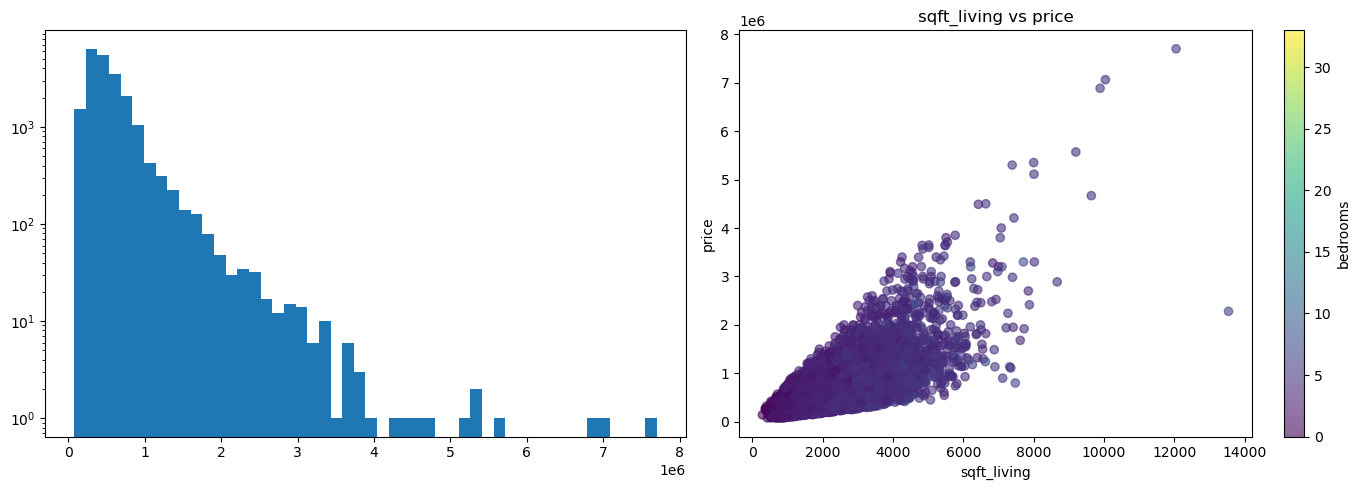

In [9]:
cmap = plt.cm.Spectral
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Завдання 3 — лівий графік: гістограма ціни
axes[0].hist(prices, 50, log=True)

# Завдання 3 — правий графік: діаграма розсіювання sqft_living vs price
sqft_livings = sales["sqft_living"]
bedrooms = sales["bedrooms"]
norm = plt.Normalize(vmin=np.min(bedrooms), vmax=np.max(bedrooms))
sc = axes[1].scatter(sqft_livings,prices,c=bedrooms,alpha=0.6)
axes[1].set_title('sqft_living vs price')
axes[1].set_xlabel('sqft_living')
axes[1].set_ylabel('price')

cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label('bedrooms')

plt.tight_layout()
plt.show()

**Спостереження (лівий графік):** Абсолютна більшість пропозицій коштує менше 300 тис. Пік пропозицій припадає на ціну менше 100 тис.

**Спостереження (правий графік):** Помітна явна кореляція між площею об'єкту пропозиції та його ціною. Хоча невеликий зсув спостерігається у бік дорожчих пропозицій. Кількість спалень, не впливає явно на ціну.

---
## Завдання 4 — Навчання та оцінка регресійної моделі

Розбийте дані 80/20 (`random_state=42`). Навчіть `LinearRegression` з scikit-learn для передбачення `price` за єдиною ознакою `sqft_living`.

1. Вкажіть вільний член (intercept) та коефіцієнт для `sqft_living`.
2. Обчисліть MSE і RMSE на тестовій вибірці.
3. Яка передбачувана ціна будинку площею 2 500 кв. футів?

In [10]:
# Поділ на навчальну та тестову вибірки
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=42)


In [11]:
# Завдання 4 — навчіть модель, вкажіть ваги, обчисліть MSE/RMSE, передбачте ціну для 2500 кв. фут.
X = train_data[["sqft_living"]].to_numpy()
y = train_data["price"].to_numpy()
#n = min(len(y), len(X))
#y = y[:n]
#X = X[:n].reshape(-1,1)

reg = LinearRegression().fit(X, y)
print(f"Independent: {reg.intercept_}")
print(f"Coefitient: {reg.coef_[0]}")
print(f"Predict: {reg.predict(np.array([[2500]]))[0]}")

living_test_data = test_data["sqft_living"].to_numpy().reshape(-1,1)
price_test_data = test_data["price"].to_numpy()
price_predicted_data = reg.predict(living_test_data)
mse = mean_squared_error(price_test_data,price_predicted_data)
rmse = np.sqrt(mse)
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

Independent: -41999.186039954424
Coefitient: 279.55477931527207
Predict: 656887.7622482257
MSE: 76484977061.77605
RMSE: 276559.1746114673


---
## Завдання 5 — Порівняння двох моделей

Навчіть другу `LinearRegression` з ознаками: `sqft_living`, `bedrooms`, `bathrooms`, `yr_built`. Порівняйте RMSE на тестовій вибірці між Моделлю 1 та Моделлю 2. Яке значення нижче? Коротко поясніть чому.

In [12]:
# Завдання 5 — модель з чотирма ознаками та порівняння RMSE
X2 = train_data[["sqft_living","bedrooms","bathrooms","yr_built"]].to_numpy()
reg2 = LinearRegression().fit(X2, y)
X2_test = test_data[["sqft_living", "bedrooms", "bathrooms", "yr_built"]].to_numpy()
y2_test = test_data["price"].to_numpy()
pred2 = reg2.predict(X2_test)
mse_new = mean_squared_error(y2_test,pred2)
rmse_new = np.sqrt(mse_new)
print(f"New MSE: {mse_new}")
print(f"New RMSE: {rmse_new}")
print(f"Difference: {rmse-rmse_new}")

New MSE: 69161623505.2973
New RMSE: 262985.9758719033
Difference: 13573.198739563988


**Відповідь:** Спостерігаємо нижчий (хоч і, відносно, не значно) вихідний результат. Причина полягає у ширшій вибірці критеріїв. Незначність відмінностей може полягати у більшій кількості незалежних змінних, які були не враховані, та у довільних (не систематичних) чинниках.

---
## ✨ Бонус — Аналіз залишків

Для вашої кращої моделі обчисліть вектор залишків (predicted − actual). Побудуйте гістограму. Чи виглядають залишки нормально розподіленими та центрованими навколо нуля? Що означав би систематичний ненульовий середній залишок?

In [13]:
# Бонус — аналіз залишків
# ВАШ КОД ТУТ
raise NotImplementedError

<class 'NotImplementedError'>: 

**Спостереження:** 